# Vector Error Correction Model (VECM) Parameter Estimation With Two Cointegrating Vectors

In [1]:
%reload_ext autoreload
%autoreload 2

# import system modules and set local import path
import os
import sys
import numpy
from matplotlib import pyplot

sys.path.insert(0, os.path.abspath('../../..'))

# import local modules
from lib import config
from lib.data import vecm, adf, stats, arima
from lib.plots import comparison, stack, twinx, comparison_stack, curve
from lib.data.impl.stats import OLS

# Config Plot Style
pyplot.style.use(config.glyfish_style)

In [2]:
def adf_test(xt):
    for i in range(len(xt)):
        result, _ = adf.compute_adf_test(xt[i])
        if result.status_vals[1]:
            print("Not Stationary")
        else:
            print("Stationary")

def plot_vecm_simulation(t, xt, title):
    labels = [r"$x_1$", r"$x_2$", r"$x_3$"]   
    comparison(xt, t, labels =labels, title=title, xlabel=r"$t$", lw=1, title_offset=0.05)

def plot_vecm_dff(dxt, title):
    labels = [r"$\Delta x_1$", r"$\Delta x_2$", r"$\Delta x_3$"]   
    stack(dxt, title=title, ylabels=labels, xlabel=r"$t$", lw=1, title_offset=0.05, figsize=(10, 8))

def pacf_acf_plot(t, dxt, nlags, title):
    acf = [stats.compute_acf(t, samp, nlags=nlags) for samp in dxt] 
    pacf = [arima.compute_pacf(samp, nlags=nlags) for samp in dxt]
    data = [[acf[i][1], pacf[i][1]] for i in range(len(dxt))]
    time = [[acf[i][0], pacf[i][0]] for i in range(len(dxt))]
    comparison_stack(data, time, title=title, xlabel=r"Lag", ylim=(-0.4, 1.0), figsize=(10, 8), 
                     labels=[["ACF", "PACF"]], ylabels=[r"$\Delta x_1$", r"$\Delta x_2$", r"$\Delta x_3$"])

## VECM(1) Two Cointegrating Vectors

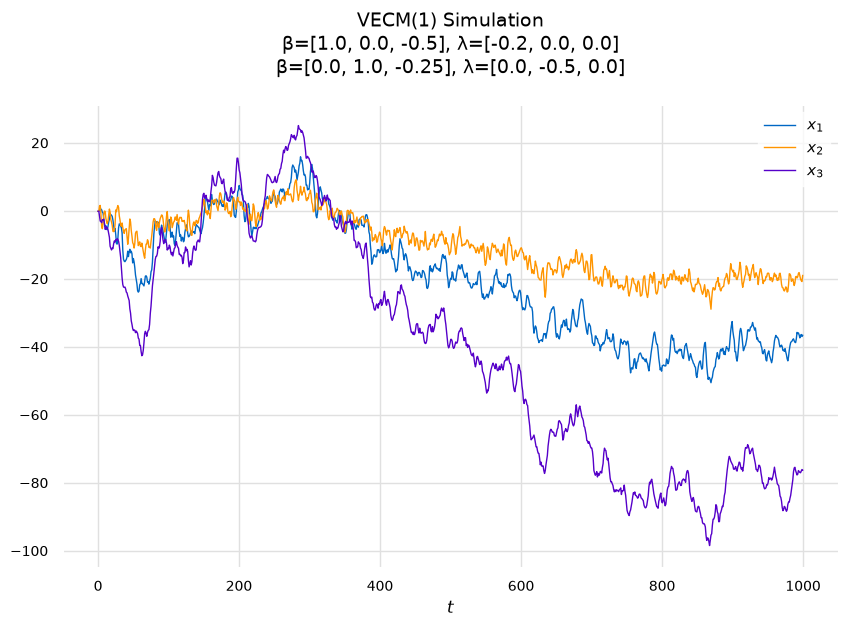

In [3]:
λ = numpy.matrix([[-0.2, 0.0, 0.0],
                  [0.0, -0.5, 0.0]]).T
β = numpy.matrix([[1.0, 0.0, -0.5],
                  [0.0, 1.0, -0.25]])
a = numpy.matrix([[0.5, 0.0, 0.0],
                  [0.0, 0.5, 0.0],
                  [0.0, 0.0, 0.5]])
Ω = numpy.matrix([[1.0, 0.0, 0.0],
                  [0.0, 1.0, 0.0],
                  [0.0, 0.0, 1.0]])

title = f"VECM(1) Simulation\nβ=[{β[0,0]}, {β[0,1]}, {β[0,2]}], λ=[{λ[0,0]}, {λ[1,0]}, {λ[2,0]}]\nβ=[{β[1,0]}, {β[1,1]}, {β[1,2]}], λ=[{λ[0,1]}, {λ[1,1]}, {λ[2,1]}]"
t, xt = vecm.create_vecm1_source(λ, β, a, Ω=Ω)
plot_vecm_simulation(t, xt, title)

### Stationarity Test

In [4]:
adf_test(xt)

Not Stationary
Not Stationary
Not Stationary


In [5]:
dt, dxt = stats.compute_diff(t, xt)
adf_test(dxt)

Stationary
Stationary
Stationary


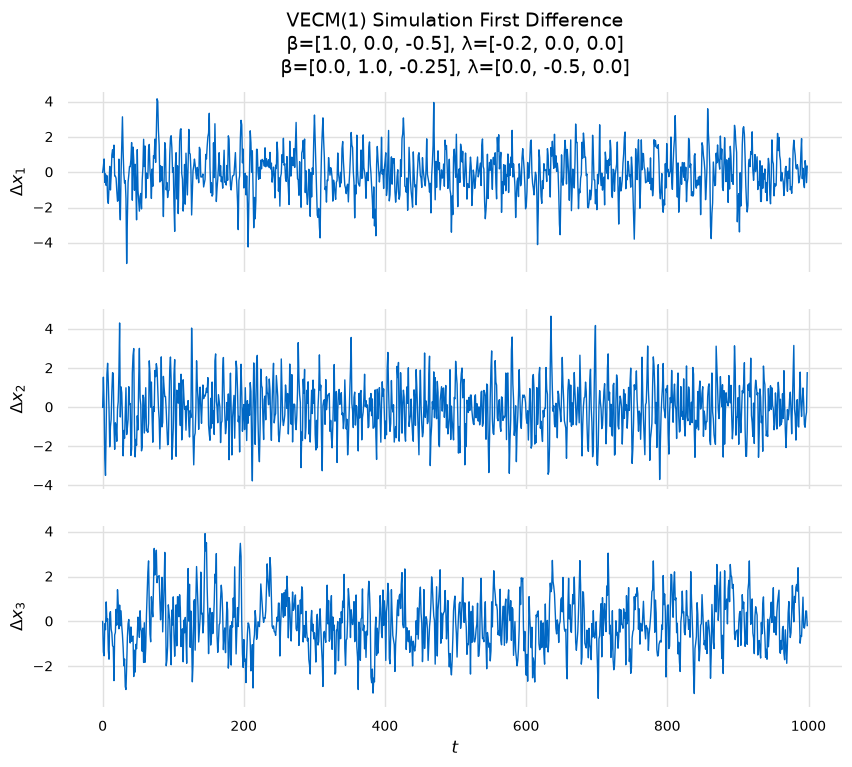

In [6]:
title = f"VECM(1) Simulation First Difference\nβ=[{β[0,0]}, {β[0,1]}, {β[0,2]}], λ=[{λ[0,0]}, {λ[1,0]}, {λ[2,0]}]\nβ=[{β[1,0]}, {β[1,1]}, {β[1,2]}], λ=[{λ[0,1]}, {λ[1,1]}, {λ[2,1]}]"
plot_vecm_dff(dxt, title)

### Order Determination

In [7]:
result, result_model = vecm.compute_order(xt, maxlags=4)
result.summary()

,AIC,BIC,FPE,HQIC
0,1.008,1.082,2.739,1.036
1,0.07237*,0.1906*,1.075*,0.1173*
2,0.07480,0.2374,1.078,0.1366
3,0.08863,0.2956,1.093,0.1673
4,0.1009,0.3522,1.106,0.1964


In [8]:
print(result_model.to_json(pretty=True))

{
   "_VAROrderTestReport__test_id": "19a86205-493b-4192-862d-3e3baacd4084",
   "_VAROrderTestReport__order": {
      "test_id": "19a86205-493b-4192-862d-3e3baacd4084",
      "label": "$\\tau_{min}$",
      "value": 1
   },
   "_VAROrderTestReport__aic": {
      "test_id": "19a86205-493b-4192-862d-3e3baacd4084",
      "order": {
         "test_id": "19a86205-493b-4192-862d-3e3baacd4084",
         "label": "$\\tau_{AIC}$",
         "value": 1
      },
      "error_metric": "AIC",
      "value": {
         "test_id": "19a86205-493b-4192-862d-3e3baacd4084",
         "label": "$\\varepsilon_{AIC}$",
         "value": 0.07237067395359087
      }
   },
   "_VAROrderTestReport__bic": {
      "test_id": "19a86205-493b-4192-862d-3e3baacd4084",
      "order": {
         "test_id": "19a86205-493b-4192-862d-3e3baacd4084",
         "label": "$\\tau_{BIC}$",
         "value": 1
      },
      "error_metric": "BIC",
      "value": {
         "test_id": "19a86205-493b-4192-862d-3e3baacd4084",
        

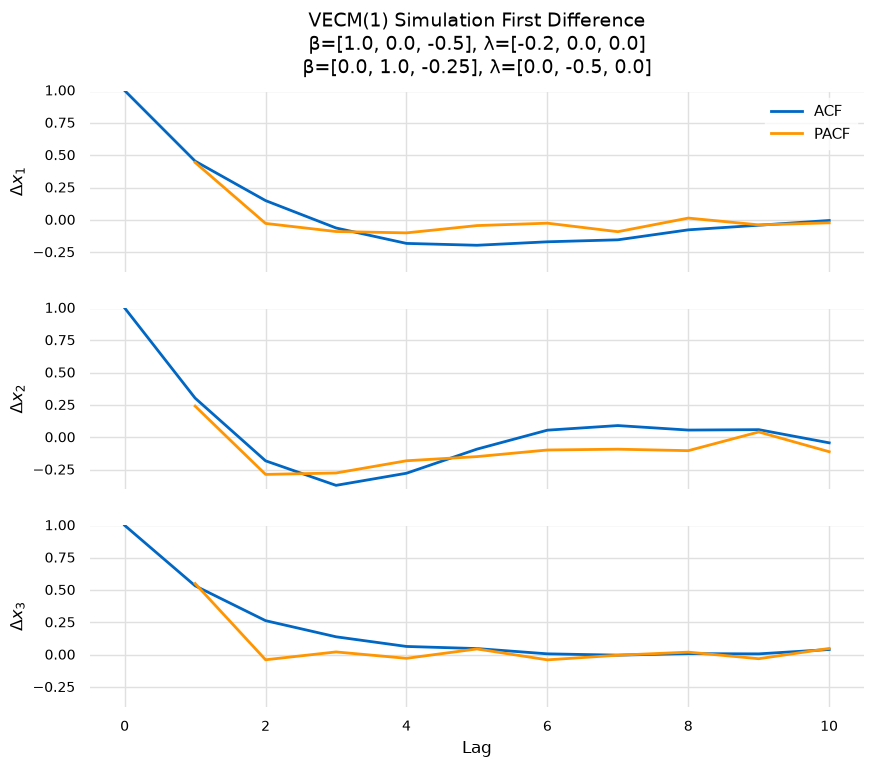

In [9]:
nlags = 10
title = f"VECM(1) Simulation First Difference\nβ=[{β[0,0]}, {β[0,1]}, {β[0,2]}], λ=[{λ[0,0]}, {λ[1,0]}, {λ[2,0]}]\nβ=[{β[1,0]}, {β[1,1]}, {β[1,2]}], λ=[{λ[0,1]}, {λ[1,1]}, {λ[2,1]}]"
pacf_acf_plot(dt, dxt, 10, title)

### $\Delta X_t$ Parameter Estimation

In [10]:
result, _ = arima.compute_ar_estimate(dxt[0], order=1)
result.summary()

<class 'statsmodels.iolib.summary.Summary'>
"""
                               SARIMAX Results                                
==============================================================================
Dep. Variable:                      y   No. Observations:                  999
Model:                 ARIMA(1, 0, 0)   Log Likelihood               -1539.410
Date:                Sun, 23 Aug 2026   AIC                           3084.819
Time:                        17:39:34   BIC                           3099.539
Sample:                             0   HQIC                          3090.414
                                - 999                                         
Covariance Type:                  opg                                         
==============================================================================
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
const         -0.0362      0.066     -0.552      0.581      -0.165       0.092
ar.L1          0.4541      0.027     16.701      0.000       0.401       0.507
sigma2         1.2761      0.055     23.142      0.000       1.168       1.384
===================================================================================
Ljung-Box (L1) (Q):                   1.10   Jarque-Bera (JB):                 1.68
Prob(Q):                              0.29   Prob(JB):                         0.43
Heteroskedasticity (H):               0.84   Skew:                            -0.04
Prob(H) (two-sided):                  0.11   Kurtosis:                         3.18
===================================================================================

Warnings:
[1] Covariance matrix calculated using the outer product of gradients (complex-step).
"""

In [11]:
result, _ = arima.compute_ar_estimate(dxt[1], order=1)
result.summary()

<class 'statsmodels.iolib.summary.Summary'>
"""
                               SARIMAX Results                                
==============================================================================
Dep. Variable:                      y   No. Observations:                  999
Model:                 ARIMA(1, 0, 0)   Log Likelihood               -1657.918
Date:                Sun, 23 Aug 2026   AIC                           3321.836
Time:                        17:39:34   BIC                           3336.556
Sample:                             0   HQIC                          3327.431
                                - 999                                         
Covariance Type:                  opg                                         
==============================================================================
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
const         -0.0181      0.058     -0.313      0.754      -0.132       0.095
ar.L1          0.3035      0.030     10.193      0.000       0.245       0.362
sigma2         1.6180      0.074     21.931      0.000       1.473       1.763
===================================================================================
Ljung-Box (L1) (Q):                   8.43   Jarque-Bera (JB):                 0.73
Prob(Q):                              0.00   Prob(JB):                         0.69
Heteroskedasticity (H):               0.84   Skew:                             0.06
Prob(H) (two-sided):                  0.11   Kurtosis:                         2.93
===================================================================================

Warnings:
[1] Covariance matrix calculated using the outer product of gradients (complex-step).
"""

In [12]:
result, _ = arima.compute_ar_estimate(dxt[2], order=1)
result.summary()

<class 'statsmodels.iolib.summary.Summary'>
"""
                               SARIMAX Results                                
==============================================================================
Dep. Variable:                      y   No. Observations:                  999
Model:                 ARIMA(1, 0, 0)   Log Likelihood               -1427.943
Date:                Sun, 23 Aug 2026   AIC                           2861.885
Time:                        17:39:34   BIC                           2876.606
Sample:                             0   HQIC                          2867.480
                                - 999                                         
Covariance Type:                  opg                                         
==============================================================================
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
const         -0.0763      0.069     -1.111      0.267      -0.211       0.058
ar.L1          0.5325      0.026     20.571      0.000       0.482       0.583
sigma2         1.0207      0.049     20.738      0.000       0.924       1.117
===================================================================================
Ljung-Box (L1) (Q):                   0.25   Jarque-Bera (JB):                 3.23
Prob(Q):                              0.62   Prob(JB):                         0.20
Heteroskedasticity (H):               0.87   Skew:                            -0.01
Prob(H) (two-sided):                  0.19   Kurtosis:                         2.72
===================================================================================

Warnings:
[1] Covariance matrix calculated using the outer product of gradients (complex-step).
"""

### Granger Causality

In [13]:
result, result_model = stats.compute_causality_matrix(dxt, nlags=1)


Granger Causality
number of lags (no zero) 1
ssr based F test:         F=0.0000  , p=1.0000  , df_denom=996, df_num=1
ssr based chi2 test:   chi2=0.0000  , p=1.0000  , df=1
likelihood ratio test: chi2=-0.0000 , p=1.0000  , df=1
parameter F test:         F=259.3609, p=0.0000  , df_denom=996, df_num=1

Granger Causality
number of lags (no zero) 1
ssr based F test:         F=1.7633  , p=0.1845  , df_denom=995, df_num=1
ssr based chi2 test:   chi2=1.7686  , p=0.1836  , df=1
likelihood ratio test: chi2=1.7671  , p=0.1837  , df=1
parameter F test:         F=1.7633  , p=0.1845  , df_denom=995, df_num=1

Granger Causality
number of lags (no zero) 1
ssr based F test:         F=38.7519 , p=0.0000  , df_denom=995, df_num=1
ssr based chi2 test:   chi2=38.8687 , p=0.0000  , df=1
likelihood ratio test: chi2=38.1309 , p=0.0000  , df=1
parameter F test:         F=38.7519 , p=0.0000  , df_denom=995, df_num=1

Granger Causality
number of lags (no zero) 1
ssr based F test:         F=0.0279  , p=0.8675  

In [14]:
result.head(10)

,pvalue,critical_value,result,dependent_var,causal_var
1,1.0000,0.05,False,1,1
2,0.1845,0.05,False,1,2
3,0.0000,0.05,True,1,3
4,0.8675,0.05,False,2,1
5,1.0000,0.05,False,2,2
6,0.0000,0.05,True,2,3
7,0.3892,0.05,False,3,1
8,0.9344,0.05,False,3,2
9,1.0000,0.05,False,3,3


In [15]:
print(result_model.to_json(pretty=True))

{
   "test_id": "8a4edceb-9e68-4ed6-ad68-944b46c45d84",
   "rank": 2,
   "results": [
      {
         "_GrangerCausalityTestResult__est_id": "8a4edceb-9e68-4ed6-ad68-944b46c45d84",
         "_GrangerCausalityTestResult__dependent_var": 1,
         "_GrangerCausalityTestResult__causal_var": 1,
         "_GrangerCausalityTestResult__pvalue": 1.0,
         "_GrangerCausalityTestResult__critical_value": 0.05,
         "_GrangerCausalityTestResult__result": false
      },
      {
         "_GrangerCausalityTestResult__est_id": "8a4edceb-9e68-4ed6-ad68-944b46c45d84",
         "_GrangerCausalityTestResult__dependent_var": 1,
         "_GrangerCausalityTestResult__causal_var": 2,
         "_GrangerCausalityTestResult__pvalue": 0.1845,
         "_GrangerCausalityTestResult__critical_value": 0.05,
         "_GrangerCausalityTestResult__result": false
      },
      {
         "_GrangerCausalityTestResult__est_id": "8a4edceb-9e68-4ed6-ad68-944b46c45d84",
         "_GrangerCausalityTestResult__de

### Johansen Test for Cointegration

In [16]:
result, result_model, _ = vecm.compute_johansen_coint_test(xt, 1)

/Users/troy/.pyenv/versions/alef-3.14.7/lib/python3.14/site-packages/statsmodels/tsa/vector_ar/vecm.py:731: ComplexWarning: Casting complex values to real discards the imaginary part
  lr1[i] = -t * np.sum(tmp, 0)
/Users/troy/.pyenv/versions/alef-3.14.7/lib/python3.14/site-packages/statsmodels/tsa/vector_ar/vecm.py:732: ComplexWarning: Casting complex values to real discards the imaginary part
  lr2[i] = -t * np.log(1 - a[i])


In [17]:
result.summary()

Trace Statistic
╒═══════════════════╤══════════════════╤══════════════════════╤══════════════════════╤══════════════════════╕
│ Null Hypothesis   │   Test Statistic │   Critical Value 90% │   Critical Value 95% │   Critical Value 99% │
╞═══════════════════╪══════════════════╪══════════════════════╪══════════════════════╪══════════════════════╡
│ r <= 0            │          645.586 │               27.067 │               29.796 │               35.463 │
├───────────────────┼──────────────────┼──────────────────────┼──────────────────────┼──────────────────────┤
│ r <= 1            │          195.936 │               13.429 │               15.494 │               19.935 │
├───────────────────┼──────────────────┼──────────────────────┼──────────────────────┼──────────────────────┤
│ r <= 2            │            1.075 │                2.705 │                3.841 │                6.635 │
╘═══════════════════╧══════════════════╧══════════════════════╧══════════════════════╧══════════════════

/Users/troy/.pyenv/versions/alef-3.14.7/lib/python3.14/site-packages/tabulate/__init__.py:897: ComplexWarning: Casting complex values to real discards the imaginary part
  conv(string)
/Users/troy/.pyenv/versions/alef-3.14.7/lib/python3.14/site-packages/tabulate/__init__.py:1381: ComplexWarning: Casting complex values to real discards the imaginary part
  return format(float(val), floatfmt)


In [18]:
print(result_model.to_json(pretty=True))

{
   "test_id": "f7ee7184-affb-4403-921c-f4822ee3ac75",
   "trace_test": [
      {
         "test_id": "f7ee7184-affb-4403-921c-f4822ee3ac75",
         "test_rank": 0,
         "null_hypothesis": "r<=0",
         "test_stat": 645.5864276225177,
         "critical_values": [
            27.0669,
            29.7961,
            35.4628
         ],
         "significance_levels": [
            "Critical Value 90%",
            "Critical Value 95%",
            "Critical Value 99%"
         ],
         "test_result": [
            true,
            true,
            true
         ]
      },
      {
         "test_id": "f7ee7184-affb-4403-921c-f4822ee3ac75",
         "test_rank": 1,
         "null_hypothesis": "r<=1",
         "test_stat": 195.9356384887924,
         "critical_values": [
            13.4294,
            15.4943,
            19.9349
         ],
         "significance_levels": [
            "Critical Value 90%",
            "Critical Value 95%",
            "Critical Value 9

### VECM Parameter Estimation

```
λ = numpy.matrix([[-0.2, 0.0, 0.0],
                  [0.0, -0.5, 0.0]]).T
β = numpy.matrix([[1.0, 0.0, -0.5],
                  [0.0, 1.0, -0.25]])
a = numpy.matrix([[0.5, 0.0, 0.0],
                  [0.0, 0.5, 0.0],
                  [0.0, 0.0, 0.5]])
Ω = numpy.matrix([[1.0, 0.0, 0.0],
                  [0.0, 1.0, 0.0],
                  [0.0, 0.0, 1.0]])
```

In [19]:
result, result_model = vecm.compute_estimate(xt, maxlags=1, rank=2)
result.summary()

,coef,std err,z,P>|z|,[0.025,0.975]
const,-0.0338,0.032,-1.057,0.291,-0.096,0.029
L1.y1,0.4934,0.026,18.906,0.000,0.442,0.545
L1.y2,-0.0201,0.026,-0.759,0.448,-0.072,0.032
L1.y3,0.0390,0.030,1.290,0.197,-0.020,0.098
,coef,std err,z,P>|z|,[0.025,0.975]
const,-0.0167,0.032,-0.525,0.600,-0.079,0.046
L1.y1,0.0264,0.026,1.017,0.309,-0.025,0.077
L1.y2,0.5277,0.026,20.003,0.000,0.476,0.579
L1.y3,-0.0222,0.030,-0.738,0.461,-0.081,0.037
,coef,std err,z,P>|z|,[0.025,0.975]


In [20]:
print(result_model.to_json(pretty=True))

{
   "est_model": "VECM",
   "rank": 2,
   "const": [
      {
         "est": -0.03379198152929229,
         "err": 0.031974800041873364,
         "est_label": "$\\hat{M}$",
         "err_label": "$\\sigma_{M}$",
         "row": 0,
         "column": 0,
         "order": 0,
         "est_id": "5b80a8d5-5e69-4ccf-8bda-3024e3d8ff11",
         "param_type": "VECM_CONST"
      },
      {
         "est": -0.016711975655074533,
         "err": 0.03185374538593314,
         "est_label": "$\\hat{M}$",
         "err_label": "$\\sigma_{M}$",
         "row": 1,
         "column": 0,
         "order": 0,
         "est_id": "5b80a8d5-5e69-4ccf-8bda-3024e3d8ff11",
         "param_type": "VECM_CONST"
      },
      {
         "est": -0.03705020912721528,
         "err": 0.032095627756040405,
         "est_label": "$\\hat{M}$",
         "err_label": "$\\sigma_{M}$",
         "row": 2,
         "column": 0,
         "order": 0,
         "est_id": "5b80a8d5-5e69-4ccf-8bda-3024e3d8ff11",
         "param_

In [21]:
beta_est = result.beta

### Verify Error Correction term Residual Stationarity

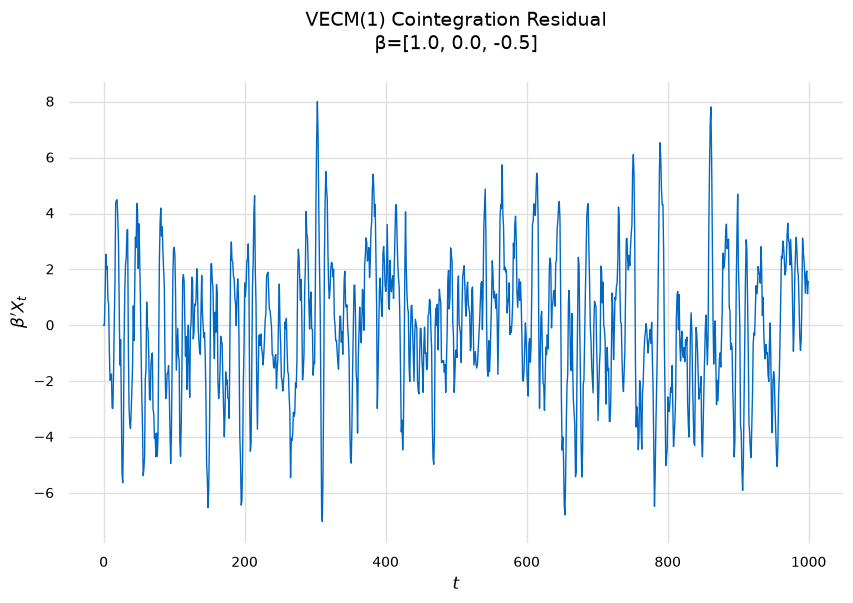

In [22]:
coint = beta_est.T[0] * xt.T / beta_est.T[0][0]
residual = numpy.sum(coint, axis=1)

title = f"VECM(1) Cointegration Residual\nβ=[{β[0,0]}, {β[0,1]}, {β[0,2]}]"
curve(residual, title=title, xlabel=r"$t$", ylabel=r"$\beta^\prime X_t$", lw=1, title_offset=0.05)

In [23]:
result, _ = adf.compute_adf_test(residual)
result.summary()

╒════════════════╤═══════════════╕
│ Test Statistic │ -13.6751      │
├────────────────┼───────────────┤
│ pvalue         │   8.44157e-25 │
├────────────────┼───────────────┤
│ Lags           │   2           │
├────────────────┼───────────────┤
│ Number Obs     │ 997           │
╘════════════════╧═══════════════╛
╒════════════════╤══════════════════╤══════════╕
│ Significance   │   Critical Value │ Result   │
╞════════════════╪══════════════════╪══════════╡
│ 1%             │         -2.56799 │ Failed   │
├────────────────┼──────────────────┼──────────┤
│ 5%             │         -1.94127 │ Failed   │
├────────────────┼──────────────────┼──────────┤
│ 10%            │         -1.61656 │ Failed   │
╘════════════════╧══════════════════╧══════════╛


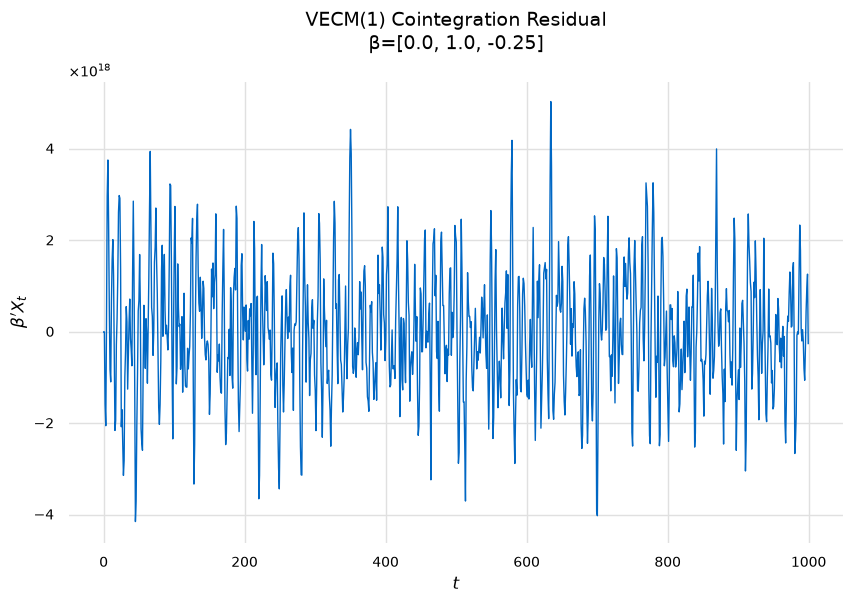

In [24]:
coint = beta_est.T[1] * xt.T / beta_est.T[1][0]
residual = numpy.sum(coint, axis=1)

title = f"VECM(1) Cointegration Residual\nβ=[{β[1,0]}, {β[1,1]}, {β[1,2]}]"
curve(residual, title=title, xlabel=r"$t$", ylabel=r"$\beta^\prime X_t$", lw=1, title_offset=0.05)

In [25]:
result, _ = adf.compute_adf_test(residual)
result.summary()

╒════════════════╤══════════╕
│ Test Statistic │ -19.8996 │
├────────────────┼──────────┤
│ pvalue         │   0      │
├────────────────┼──────────┤
│ Lags           │   2      │
├────────────────┼──────────┤
│ Number Obs     │ 997      │
╘════════════════╧══════════╛
╒════════════════╤══════════════════╤══════════╕
│ Significance   │   Critical Value │ Result   │
╞════════════════╪══════════════════╪══════════╡
│ 1%             │         -2.56799 │ Failed   │
├────────────────┼──────────────────┼──────────┤
│ 5%             │         -1.94127 │ Failed   │
├────────────────┼──────────────────┼──────────┤
│ 10%            │         -1.61656 │ Failed   │
╘════════════════╧══════════════════╧══════════╛


## VECM(2) Two Cointegrating Vectors

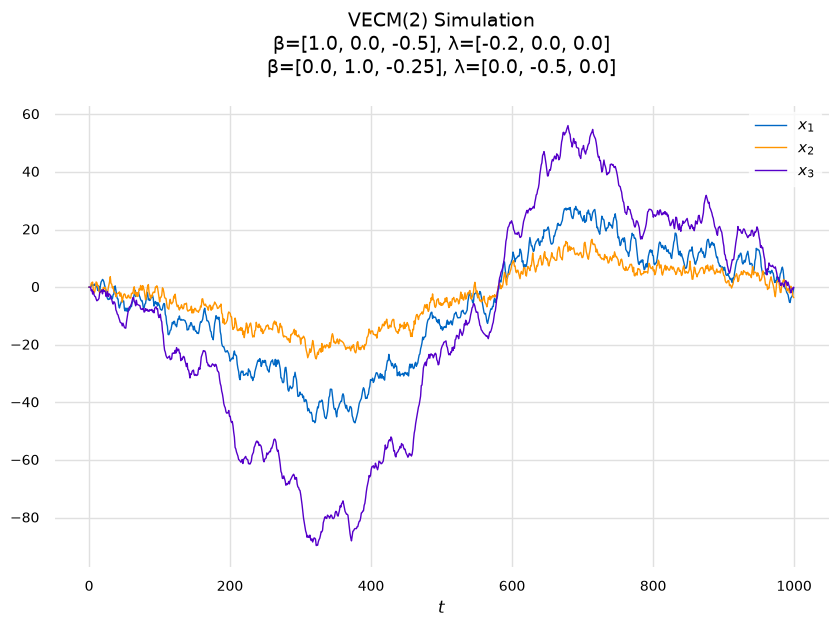

In [26]:
λ = numpy.matrix([[-0.2, 0.0, 0.0],
                  [0.0, -0.5, 0.0]]).T
β = numpy.matrix([[1.0, 0.0, -0.5],
                  [0.0, 1.0, -0.25]])
a = numpy.array([[[0.25, 0.0, 0.0],
                  [0.0, 0.25, 0.0],
                  [0.0, 0.0, 0.25]],
                 [[0.25, 0.0, 0.0],
                  [0.0, 0.25, 0.0],
                  [0.0, 0.0, 0.25]]])
Ω = numpy.matrix([[1.0, 0.0, 0.0],
                  [0.0, 1.0, 0.0],
                  [0.0, 0.0, 1.0]])

title = f"VECM(2) Simulation\nβ=[{β[0,0]}, {β[0,1]}, {β[0,2]}], λ=[{λ[0,0]}, {λ[1,0]}, {λ[2,0]}]\nβ=[{β[1,0]}, {β[1,1]}, {β[1,2]}], λ=[{λ[0,1]}, {λ[1,1]}, {λ[2,1]}]"
t, xt = vecm.create_vecm_source(λ, β, a, Ω=Ω)
plot_vecm_simulation(t, xt, title)

### Stationarity Test

In [27]:
adf_test(xt)

Not Stationary
Not Stationary
Not Stationary


In [28]:
dt, dxt = stats.compute_diff(t, xt)
adf_test(dxt)

Stationary
Stationary
Stationary


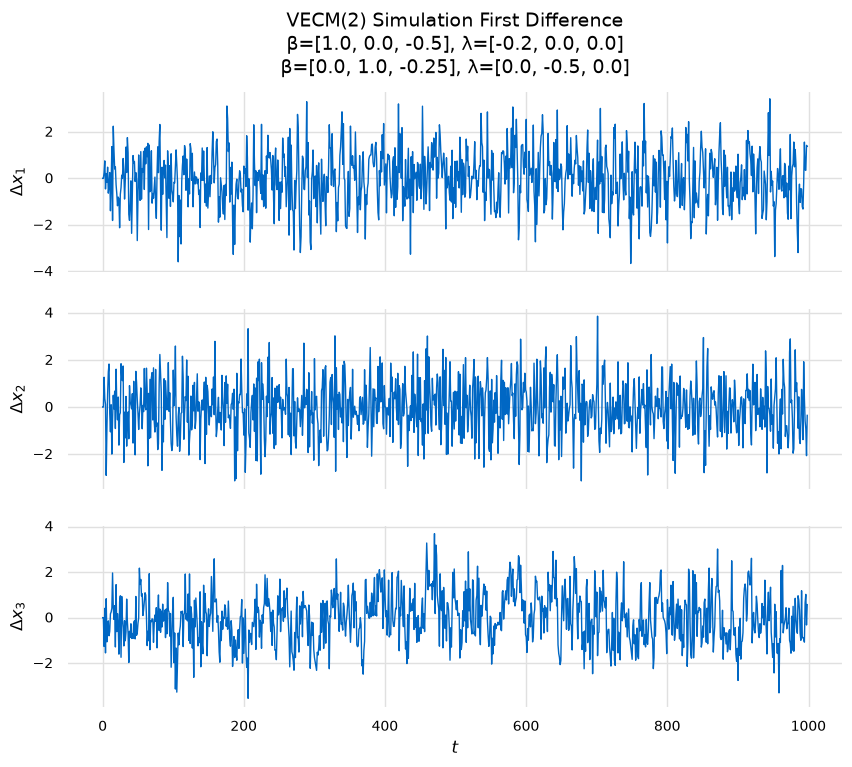

In [29]:
title = f"VECM(2) Simulation First Difference\nβ=[{β[0,0]}, {β[0,1]}, {β[0,2]}], λ=[{λ[0,0]}, {λ[1,0]}, {λ[2,0]}]\nβ=[{β[1,0]}, {β[1,1]}, {β[1,2]}], λ=[{λ[0,1]}, {λ[1,1]}, {λ[2,1]}]"
plot_vecm_dff(dxt, title)

### Order Determination

In [30]:
result, result_model = vecm.compute_order(xt, maxlags=6)
result.summary()

,AIC,BIC,FPE,HQIC
0,0.5216,0.5957,1.685,0.5498
1,0.2097,0.3281,1.233,0.2547
2,0.03377*,0.1966*,1.034*,0.09569*
3,0.04479,0.2521,1.046,0.1236
4,0.05730,0.3090,1.059,0.1530
5,0.06805,0.3642,1.070,0.1806
6,0.08151,0.4220,1.085,0.2110


In [31]:
print(result_model.to_json(pretty=True))

{
   "_VAROrderTestReport__test_id": "35b761c0-06b4-4572-b447-7041f0cde371",
   "_VAROrderTestReport__order": {
      "test_id": "35b761c0-06b4-4572-b447-7041f0cde371",
      "label": "$\\tau_{min}$",
      "value": 2
   },
   "_VAROrderTestReport__aic": {
      "test_id": "35b761c0-06b4-4572-b447-7041f0cde371",
      "order": {
         "test_id": "35b761c0-06b4-4572-b447-7041f0cde371",
         "label": "$\\tau_{AIC}$",
         "value": 2
      },
      "error_metric": "AIC",
      "value": {
         "test_id": "35b761c0-06b4-4572-b447-7041f0cde371",
         "label": "$\\varepsilon_{AIC}$",
         "value": 0.03377130807591533
      }
   },
   "_VAROrderTestReport__bic": {
      "test_id": "35b761c0-06b4-4572-b447-7041f0cde371",
      "order": {
         "test_id": "35b761c0-06b4-4572-b447-7041f0cde371",
         "label": "$\\tau_{BIC}$",
         "value": 2
      },
      "error_metric": "BIC",
      "value": {
         "test_id": "35b761c0-06b4-4572-b447-7041f0cde371",
        

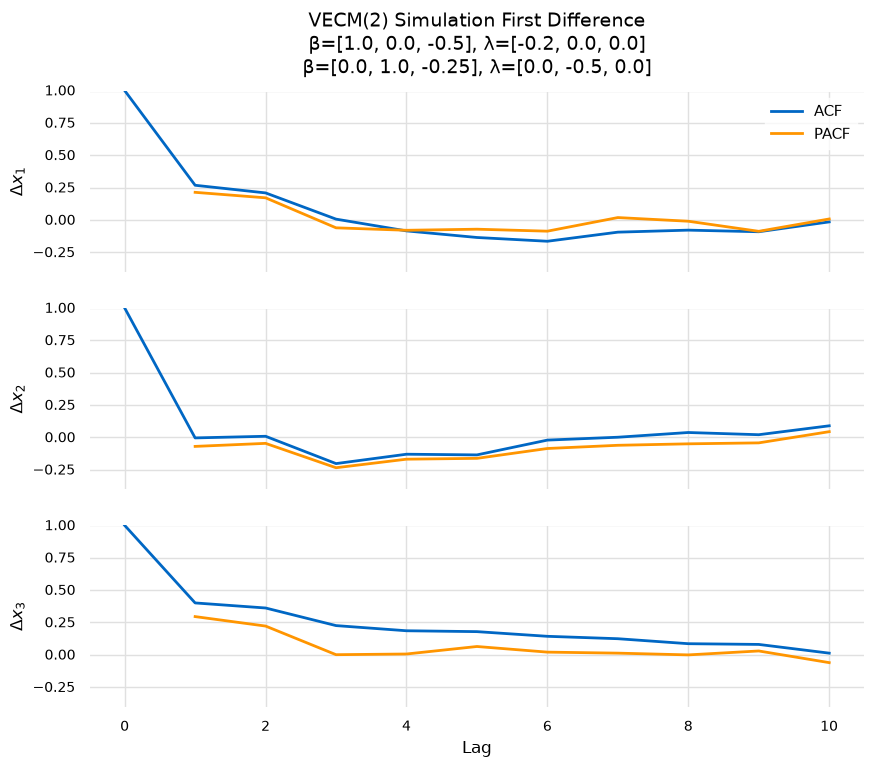

In [32]:
nlags = 10
title = f"VECM(2) Simulation First Difference\nβ=[{β[0,0]}, {β[0,1]}, {β[0,2]}], λ=[{λ[0,0]}, {λ[1,0]}, {λ[2,0]}]\nβ=[{β[1,0]}, {β[1,1]}, {β[1,2]}], λ=[{λ[0,1]}, {λ[1,1]}, {λ[2,1]}]"
pacf_acf_plot(dt, dxt, 10, title)

### $\Delta X_t$ Parameter Estimation

In [33]:
result, _ = arima.compute_ar_estimate(dxt[0], order=2)
result.summary()

<class 'statsmodels.iolib.summary.Summary'>
"""
                               SARIMAX Results                                
==============================================================================
Dep. Variable:                      y   No. Observations:                  999
Model:                 ARIMA(2, 0, 0)   Log Likelihood               -1548.030
Date:                Sun, 23 Aug 2026   AIC                           3104.061
Time:                        17:39:35   BIC                           3123.688
Sample:                             0   HQIC                          3111.521
                                - 999                                         
Covariance Type:                  opg                                         
==============================================================================
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
const          0.0009      0.058      0.016      0.987      -0.113       0.114
ar.L1          0.2286      0.032      7.093      0.000       0.165       0.292
ar.L2          0.1481      0.031      4.772      0.000       0.087       0.209
sigma2         1.2984      0.058     22.296      0.000       1.184       1.413
===================================================================================
Ljung-Box (L1) (Q):                   0.18   Jarque-Bera (JB):                 0.62
Prob(Q):                              0.67   Prob(JB):                         0.73
Heteroskedasticity (H):               0.97   Skew:                            -0.06
Prob(H) (two-sided):                  0.80   Kurtosis:                         3.00
===================================================================================

Warnings:
[1] Covariance matrix calculated using the outer product of gradients (complex-step).
"""

In [34]:
result, _ = arima.compute_ar_estimate(dxt[1], order=2)
result.summary()

<class 'statsmodels.iolib.summary.Summary'>
"""
                               SARIMAX Results                                
==============================================================================
Dep. Variable:                      y   No. Observations:                  999
Model:                 ARIMA(2, 0, 0)   Log Likelihood               -1559.903
Date:                Sun, 23 Aug 2026   AIC                           3127.807
Time:                        17:39:35   BIC                           3147.434
Sample:                             0   HQIC                          3135.267
                                - 999                                         
Covariance Type:                  opg                                         
==============================================================================
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
const         -0.0036      0.037     -0.098      0.922      -0.076       0.068
ar.L1         -0.0041      0.032     -0.128      0.898      -0.067       0.058
ar.L2          0.0085      0.029      0.289      0.772      -0.049       0.066
sigma2         1.3298      0.061     21.736      0.000       1.210       1.450
===================================================================================
Ljung-Box (L1) (Q):                   0.00   Jarque-Bera (JB):                 0.54
Prob(Q):                              0.96   Prob(JB):                         0.76
Heteroskedasticity (H):               0.85   Skew:                             0.02
Prob(H) (two-sided):                  0.14   Kurtosis:                         2.90
===================================================================================

Warnings:
[1] Covariance matrix calculated using the outer product of gradients (complex-step).
"""

In [35]:
result, _ = arima.compute_ar_estimate(dxt[2], order=2)
result.summary()

<class 'statsmodels.iolib.summary.Summary'>
"""
                               SARIMAX Results                                
==============================================================================
Dep. Variable:                      y   No. Observations:                  999
Model:                 ARIMA(2, 0, 0)   Log Likelihood               -1410.551
Date:                Sun, 23 Aug 2026   AIC                           2829.102
Time:                        17:39:35   BIC                           2848.729
Sample:                             0   HQIC                          2836.562
                                - 999                                         
Covariance Type:                  opg                                         
==============================================================================
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
const          0.0004      0.070      0.006      0.996      -0.136       0.137
ar.L1          0.3044      0.031      9.684      0.000       0.243       0.366
ar.L2          0.2391      0.030      7.863      0.000       0.179       0.299
sigma2         0.9858      0.045     21.740      0.000       0.897       1.075
===================================================================================
Ljung-Box (L1) (Q):                   0.03   Jarque-Bera (JB):                 3.96
Prob(Q):                              0.86   Prob(JB):                         0.14
Heteroskedasticity (H):               1.29   Skew:                             0.15
Prob(H) (two-sided):                  0.02   Kurtosis:                         2.93
===================================================================================

Warnings:
[1] Covariance matrix calculated using the outer product of gradients (complex-step).
"""

### Granger Causality

In [36]:
result, result_model = stats.compute_causality_matrix(dxt, nlags=2)


Granger Causality
number of lags (no zero) 1
ssr based F test:         F=0.0000  , p=1.0000  , df_denom=996, df_num=1
ssr based chi2 test:   chi2=0.0000  , p=1.0000  , df=1
likelihood ratio test: chi2=-0.0000 , p=1.0000  , df=1
parameter F test:         F=77.2438 , p=0.0000  , df_denom=996, df_num=1

Granger Causality
number of lags (no zero) 2
ssr based F test:         F=0.0000  , p=1.0000  , df_denom=994, df_num=2
ssr based chi2 test:   chi2=0.0000  , p=1.0000  , df=2
likelihood ratio test: chi2=-0.0000 , p=1.0000  , df=2
parameter F test:         F=50.5861 , p=0.0000  , df_denom=994, df_num=2

Granger Causality
number of lags (no zero) 1
ssr based F test:         F=1.4915  , p=0.2223  , df_denom=995, df_num=1
ssr based chi2 test:   chi2=1.4960  , p=0.2213  , df=1
likelihood ratio test: chi2=1.4948  , p=0.2215  , df=1
parameter F test:         F=1.4915  , p=0.2223  , df_denom=995, df_num=1

Granger Causality
number of lags (no zero) 2
ssr based F test:         F=0.4188  , p=0.6580  

In [37]:
result.head(10)

,pvalue,critical_value,result,dependent_var,causal_var
1,1.0000,0.05,False,1,1
2,0.2223,0.05,False,1,2
3,0.0000,0.05,True,1,3
4,0.0118,0.05,True,2,1
5,1.0000,0.05,False,2,2
6,0.0000,0.05,True,2,3
7,0.0764,0.05,False,3,1
8,0.2981,0.05,False,3,2
9,1.0000,0.05,False,3,3


In [38]:
print(result_model.to_json(pretty=True))

{
   "test_id": "6796cac2-55d7-416a-8042-1f5d9b31b58d",
   "rank": 2,
   "results": [
      {
         "_GrangerCausalityTestResult__est_id": "6796cac2-55d7-416a-8042-1f5d9b31b58d",
         "_GrangerCausalityTestResult__dependent_var": 1,
         "_GrangerCausalityTestResult__causal_var": 1,
         "_GrangerCausalityTestResult__pvalue": 1.0,
         "_GrangerCausalityTestResult__critical_value": 0.05,
         "_GrangerCausalityTestResult__result": false
      },
      {
         "_GrangerCausalityTestResult__est_id": "6796cac2-55d7-416a-8042-1f5d9b31b58d",
         "_GrangerCausalityTestResult__dependent_var": 1,
         "_GrangerCausalityTestResult__causal_var": 2,
         "_GrangerCausalityTestResult__pvalue": 0.2223,
         "_GrangerCausalityTestResult__critical_value": 0.05,
         "_GrangerCausalityTestResult__result": false
      },
      {
         "_GrangerCausalityTestResult__est_id": "6796cac2-55d7-416a-8042-1f5d9b31b58d",
         "_GrangerCausalityTestResult__de

### Johansen Test for Cointegration

In [39]:
result, result_model, _ = vecm.compute_johansen_coint_test(xt, 2)

/Users/troy/.pyenv/versions/alef-3.14.7/lib/python3.14/site-packages/statsmodels/tsa/vector_ar/vecm.py:731: ComplexWarning: Casting complex values to real discards the imaginary part
  lr1[i] = -t * np.sum(tmp, 0)
/Users/troy/.pyenv/versions/alef-3.14.7/lib/python3.14/site-packages/statsmodels/tsa/vector_ar/vecm.py:732: ComplexWarning: Casting complex values to real discards the imaginary part
  lr2[i] = -t * np.log(1 - a[i])


In [40]:
result.summary()

Trace Statistic
╒═══════════════════╤══════════════════╤══════════════════════╤══════════════════════╤══════════════════════╕
│ Null Hypothesis   │   Test Statistic │   Critical Value 90% │   Critical Value 95% │   Critical Value 99% │
╞═══════════════════╪══════════════════╪══════════════════════╪══════════════════════╪══════════════════════╡
│ r <= 0            │          484.919 │               27.067 │               29.796 │               35.463 │
├───────────────────┼──────────────────┼──────────────────────┼──────────────────────┼──────────────────────┤
│ r <= 1            │          189.875 │               13.429 │               15.494 │               19.935 │
├───────────────────┼──────────────────┼──────────────────────┼──────────────────────┼──────────────────────┤
│ r <= 2            │            0.769 │                2.705 │                3.841 │                6.635 │
╘═══════════════════╧══════════════════╧══════════════════════╧══════════════════════╧══════════════════

/Users/troy/.pyenv/versions/alef-3.14.7/lib/python3.14/site-packages/tabulate/__init__.py:897: ComplexWarning: Casting complex values to real discards the imaginary part
  conv(string)
/Users/troy/.pyenv/versions/alef-3.14.7/lib/python3.14/site-packages/tabulate/__init__.py:1381: ComplexWarning: Casting complex values to real discards the imaginary part
  return format(float(val), floatfmt)


In [41]:
print(result_model.to_json(pretty=True))

{
   "test_id": "521d4b2f-20b6-49e1-9981-9d03e2cd1b71",
   "trace_test": [
      {
         "test_id": "521d4b2f-20b6-49e1-9981-9d03e2cd1b71",
         "test_rank": 0,
         "null_hypothesis": "r<=0",
         "test_stat": 484.9187422648862,
         "critical_values": [
            27.0669,
            29.7961,
            35.4628
         ],
         "significance_levels": [
            "Critical Value 90%",
            "Critical Value 95%",
            "Critical Value 99%"
         ],
         "test_result": [
            true,
            true,
            true
         ]
      },
      {
         "test_id": "521d4b2f-20b6-49e1-9981-9d03e2cd1b71",
         "test_rank": 1,
         "null_hypothesis": "r<=1",
         "test_stat": 189.87505740054826,
         "critical_values": [
            13.4294,
            15.4943,
            19.9349
         ],
         "significance_levels": [
            "Critical Value 90%",
            "Critical Value 95%",
            "Critical Value 

### VECM Parameter Estimation

```
λ = numpy.matrix([[-0.2, 0.0, 0.0],
                  [0.0, -0.5, 0.0]]).T
β = numpy.matrix([[1.0, 0.0, -0.5],
                  [0.0, 1.0, -0.25]])
a = numpy.array([[[0.25, 0.0, 0.0],
                  [0.0, 0.25, 0.0],
                  [0.0, 0.0, 0.25]],
                 [[0.25, 0.0, 0.0],
                  [0.0, 0.25, 0.0],
                  [0.0, 0.0, 0.25]]])
Ω = numpy.matrix([[1.0, 0.0, 0.0],
                  [0.0, 1.0, 0.0],
                  [0.0, 0.0, 1.0]])
```



In [42]:
result, result_model = vecm.compute_estimate(xt, maxlags=2, rank=2)
result.summary()

,coef,std err,z,P>|z|,[0.025,0.975]
const,-0.0420,0.033,-1.290,0.197,-0.106,0.022
L1.y1,0.2686,0.029,9.326,0.000,0.212,0.325
L1.y2,-0.0094,0.033,-0.289,0.773,-0.073,0.054
L1.y3,0.0069,0.034,0.206,0.837,-0.059,0.073
L2.y1,0.2519,0.029,8.581,0.000,0.194,0.309
L2.y2,-0.0399,0.031,-1.267,0.205,-0.102,0.022
L2.y3,-0.0360,0.034,-1.047,0.295,-0.103,0.031
,coef,std err,z,P>|z|,[0.025,0.975]
const,0.0067,0.031,0.218,0.828,-0.054,0.067
L1.y1,0.0309,0.027,1.131,0.258,-0.023,0.085


In [43]:
print(result_model.to_json(pretty=True))

{
   "est_model": "VECM",
   "rank": 2,
   "const": [
      {
         "est": -0.041985661251522144,
         "err": 0.032548938663292004,
         "est_label": "$\\hat{M}$",
         "err_label": "$\\sigma_{M}$",
         "row": 0,
         "column": 0,
         "order": 0,
         "est_id": "1ad4c8cb-14d0-4a59-9297-c5aa285e0081",
         "param_type": "VECM_CONST"
      },
      {
         "est": 0.006733741390435354,
         "err": 0.030922294901653456,
         "est_label": "$\\hat{M}$",
         "err_label": "$\\sigma_{M}$",
         "row": 1,
         "column": 0,
         "order": 0,
         "est_id": "1ad4c8cb-14d0-4a59-9297-c5aa285e0081",
         "param_type": "VECM_CONST"
      },
      {
         "est": 0.003863256633425352,
         "err": 0.03151427420500116,
         "est_label": "$\\hat{M}$",
         "err_label": "$\\sigma_{M}$",
         "row": 2,
         "column": 0,
         "order": 0,
         "est_id": "1ad4c8cb-14d0-4a59-9297-c5aa285e0081",
         "param_

In [44]:
beta_est = result.beta

### Verify Error Correction term Residual Stationarity

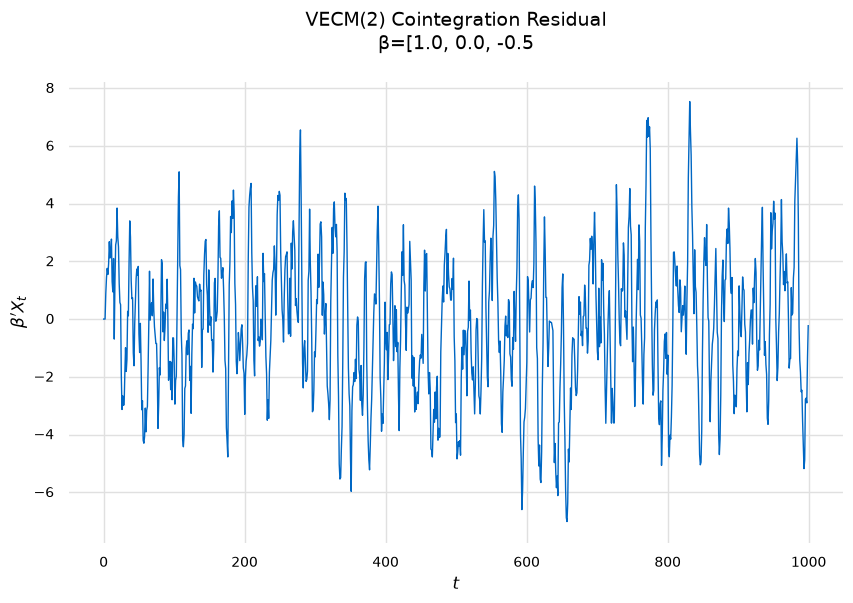

In [45]:
beta_est = result.beta
coint = beta_est.T[0] * xt.T / beta_est.T[0][0]
residual = numpy.sum(coint, axis=1)

title = f"VECM(2) Cointegration Residual\nβ=[{β[0,0]}, {β[0,1]}, {β[0,2]}"
curve(residual, title=title, xlabel=r"$t$", ylabel=r"$\beta^\prime X_t$", lw=1, title_offset=0.05)

In [46]:
result, _ = adf.compute_adf_test(residual)
result.summary()

╒════════════════╤═══════════════╕
│ Test Statistic │ -13.5026      │
├────────────────┼───────────────┤
│ pvalue         │   1.58306e-24 │
├────────────────┼───────────────┤
│ Lags           │   2           │
├────────────────┼───────────────┤
│ Number Obs     │ 997           │
╘════════════════╧═══════════════╛
╒════════════════╤══════════════════╤══════════╕
│ Significance   │   Critical Value │ Result   │
╞════════════════╪══════════════════╪══════════╡
│ 1%             │         -2.56799 │ Failed   │
├────────────────┼──────────────────┼──────────┤
│ 5%             │         -1.94127 │ Failed   │
├────────────────┼──────────────────┼──────────┤
│ 10%            │         -1.61656 │ Failed   │
╘════════════════╧══════════════════╧══════════╛


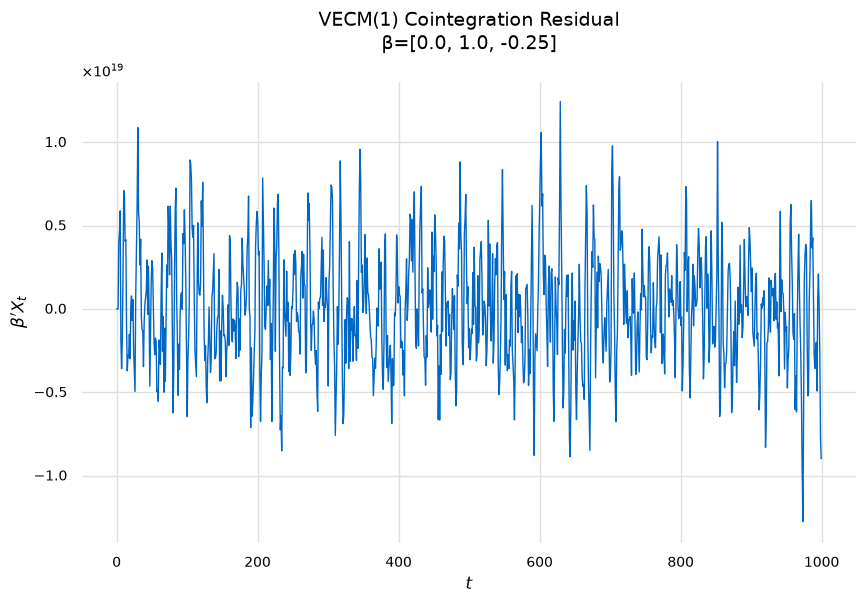

In [47]:
coint = beta_est.T[1] * xt.T / beta_est.T[1][0]
residual = numpy.sum(coint, axis=1)

title = f"VECM(1) Cointegration Residual\nβ=[{β[1,0]}, {β[1,1]}, {β[1,2]}]"
curve(residual, title=title, xlabel=r"$t$", ylabel=r"$\beta^\prime X_t$", lw=1, title_offset=0.05)

In [48]:
result, _ = adf.compute_adf_test(residual)
result.summary()

╒════════════════╤═══════════════╕
│ Test Statistic │ -18.3283      │
├────────────────┼───────────────┤
│ pvalue         │   4.18534e-29 │
├────────────────┼───────────────┤
│ Lags           │   2           │
├────────────────┼───────────────┤
│ Number Obs     │ 997           │
╘════════════════╧═══════════════╛
╒════════════════╤══════════════════╤══════════╕
│ Significance   │   Critical Value │ Result   │
╞════════════════╪══════════════════╪══════════╡
│ 1%             │         -2.56799 │ Failed   │
├────────────────┼──────────────────┼──────────┤
│ 5%             │         -1.94127 │ Failed   │
├────────────────┼──────────────────┼──────────┤
│ 10%            │         -1.61656 │ Failed   │
╘════════════════╧══════════════════╧══════════╛


## VECM(3) Two Cointegrating Vectors

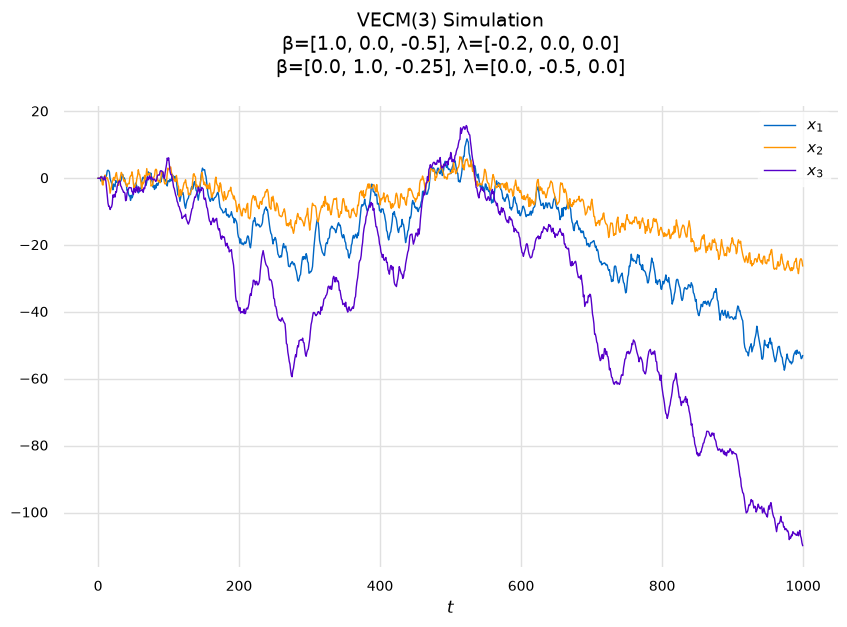

In [49]:
λ = numpy.matrix([[-0.2, 0.0, 0.0],
                  [0.0, -0.5, 0.0]]).T
β = numpy.matrix([[1.0, 0.0, -0.5],
                  [0.0, 1.0, -0.25]])
a = numpy.array([[[0.25, 0.0, 0.0],
                  [0.0, 0.25, 0.0],
                  [0.0, 0.0, 0.25]],
                 [[0.25, 0.0, 0.0],
                  [0.0, 0.25, 0.0],
                  [0.0, 0.0, 0.25]],
                 [[0.1, 0.0, 0.0],
                  [0.0, 0.1, 0.0],
                  [0.0, 0.0, 0.1]]])
Ω = numpy.matrix([[1.0, 0.0, 0.0],
                  [0.0, 1.0, 0.0],
                  [0.0, 0.0, 1.0]])

title = f"VECM(3) Simulation\nβ=[{β[0,0]}, {β[0,1]}, {β[0,2]}], λ=[{λ[0,0]}, {λ[1,0]}, {λ[2,0]}]\nβ=[{β[1,0]}, {β[1,1]}, {β[1,2]}], λ=[{λ[0,1]}, {λ[1,1]}, {λ[2,1]}]"
t, xt = vecm.create_vecm_source(λ, β, a, Ω=Ω)
plot_vecm_simulation(t, xt, title)

### Stationarity Test

In [50]:
adf_test(xt)

Not Stationary
Not Stationary
Not Stationary


In [51]:
dt, dxt = stats.compute_diff(t, xt)
adf_test(dxt)

Stationary
Stationary
Stationary


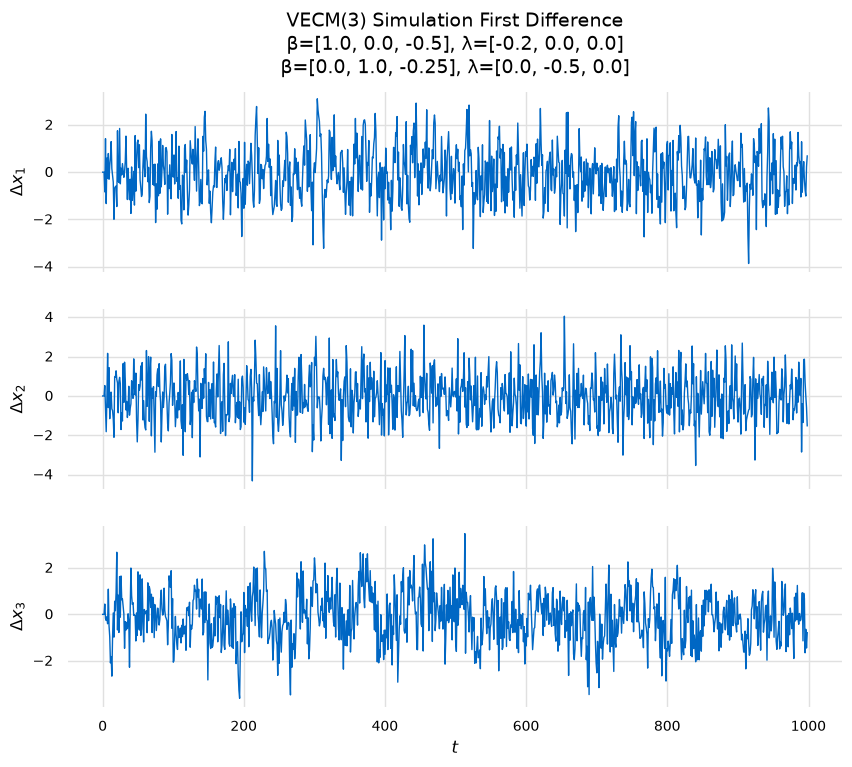

In [52]:
title = f"VECM(3) Simulation First Difference\nβ=[{β[0,0]}, {β[0,1]}, {β[0,2]}], λ=[{λ[0,0]}, {λ[1,0]}, {λ[2,0]}]\nβ=[{β[1,0]}, {β[1,1]}, {β[1,2]}], λ=[{λ[0,1]}, {λ[1,1]}, {λ[2,1]}]"
plot_vecm_dff(dxt, title)

### Order Determination

In [53]:
result, result_model = vecm.compute_order(xt, maxlags=6)
result.summary()

,AIC,BIC,FPE,HQIC
0,0.4245,0.4985,1.529,0.4526
1,0.1688,0.2872,1.184,0.2138
2,-0.02140,0.1415*,0.9788,0.04052
3,-0.05197*,0.1553,0.9494*,0.02684*
4,-0.03994,0.2118,0.9609,0.05575
5,-0.04469,0.2514,0.9563,0.06789
6,-0.03558,0.3050,0.9651,0.09389


In [54]:
print(result_model.to_json(pretty=True))

{
   "_VAROrderTestReport__test_id": "99c5c596-b327-4504-b460-0c5f93ccd4a5",
   "_VAROrderTestReport__order": {
      "test_id": "99c5c596-b327-4504-b460-0c5f93ccd4a5",
      "label": "$\\tau_{min}$",
      "value": 3
   },
   "_VAROrderTestReport__aic": {
      "test_id": "99c5c596-b327-4504-b460-0c5f93ccd4a5",
      "order": {
         "test_id": "99c5c596-b327-4504-b460-0c5f93ccd4a5",
         "label": "$\\tau_{AIC}$",
         "value": 3
      },
      "error_metric": "AIC",
      "value": {
         "test_id": "99c5c596-b327-4504-b460-0c5f93ccd4a5",
         "label": "$\\varepsilon_{AIC}$",
         "value": -0.05197046483281091
      }
   },
   "_VAROrderTestReport__bic": {
      "test_id": "99c5c596-b327-4504-b460-0c5f93ccd4a5",
      "order": {
         "test_id": "99c5c596-b327-4504-b460-0c5f93ccd4a5",
         "label": "$\\tau_{BIC}$",
         "value": 2
      },
      "error_metric": "BIC",
      "value": {
         "test_id": "99c5c596-b327-4504-b460-0c5f93ccd4a5",
       

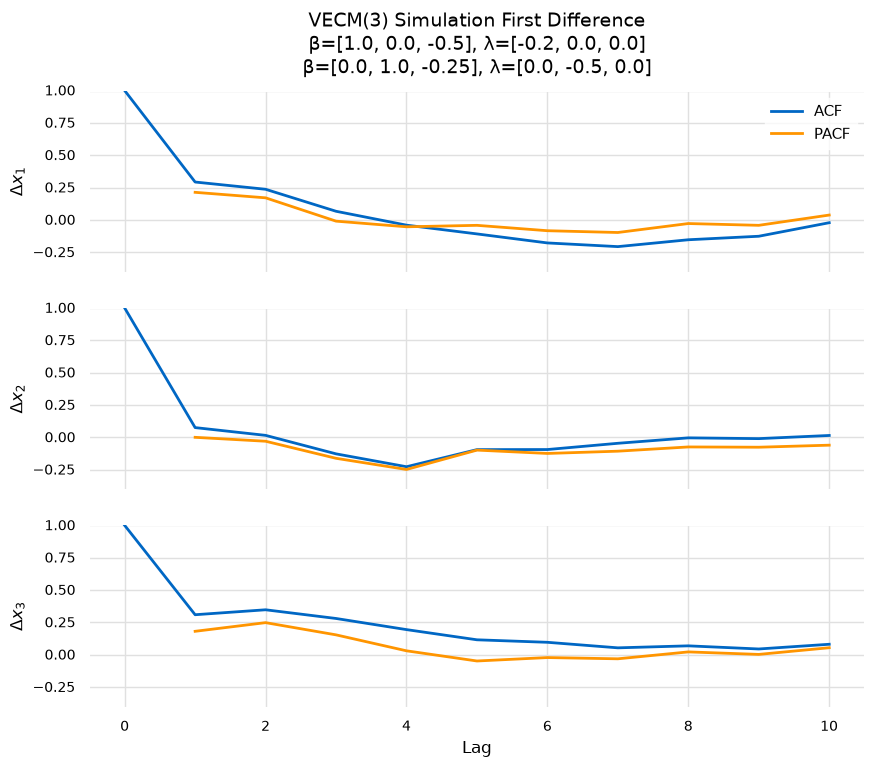

In [55]:
nlags = 10
title = f"VECM(3) Simulation First Difference\nβ=[{β[0,0]}, {β[0,1]}, {β[0,2]}], λ=[{λ[0,0]}, {λ[1,0]}, {λ[2,0]}]\nβ=[{β[1,0]}, {β[1,1]}, {β[1,2]}], λ=[{λ[0,1]}, {λ[1,1]}, {λ[2,1]}]"
pacf_acf_plot(dt, dxt, 10, title)

### $\Delta X_t$ Parameter Estimation

In [56]:
result, _ = arima.compute_ar_estimate(dxt[0], order=3)
result.summary()

<class 'statsmodels.iolib.summary.Summary'>
"""
                               SARIMAX Results                                
==============================================================================
Dep. Variable:                      y   No. Observations:                  999
Model:                 ARIMA(3, 0, 0)   Log Likelihood               -1458.874
Date:                Sun, 23 Aug 2026   AIC                           2927.748
Time:                        17:39:36   BIC                           2952.281
Sample:                             0   HQIC                          2937.073
                                - 999                                         
Covariance Type:                  opg                                         
==============================================================================
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
const         -0.0525      0.054     -0.979      0.328      -0.158       0.053
ar.L1          0.2519      0.032      7.970      0.000       0.190       0.314
ar.L2          0.1761      0.033      5.267      0.000       0.111       0.242
ar.L3         -0.0444      0.032     -1.409      0.159      -0.106       0.017
sigma2         1.0861      0.051     21.131      0.000       0.985       1.187
===================================================================================
Ljung-Box (L1) (Q):                   0.02   Jarque-Bera (JB):                 1.86
Prob(Q):                              0.90   Prob(JB):                         0.39
Heteroskedasticity (H):               1.08   Skew:                             0.01
Prob(H) (two-sided):                  0.46   Kurtosis:                         2.79
===================================================================================

Warnings:
[1] Covariance matrix calculated using the outer product of gradients (complex-step).
"""

In [57]:
result, _ = arima.compute_ar_estimate(dxt[1], order=3)
result.summary()

<class 'statsmodels.iolib.summary.Summary'>
"""
                               SARIMAX Results                                
==============================================================================
Dep. Variable:                      y   No. Observations:                  999
Model:                 ARIMA(3, 0, 0)   Log Likelihood               -1581.347
Date:                Sun, 23 Aug 2026   AIC                           3172.695
Time:                        17:39:36   BIC                           3197.228
Sample:                             0   HQIC                          3182.020
                                - 999                                         
Covariance Type:                  opg                                         
==============================================================================
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
const         -0.0261      0.036     -0.723      0.470      -0.097       0.045
ar.L1          0.0762      0.032      2.402      0.016       0.014       0.138
ar.L2          0.0196      0.032      0.615      0.539      -0.043       0.082
ar.L3         -0.1298      0.032     -4.094      0.000      -0.192      -0.068
sigma2         1.3881      0.061     22.594      0.000       1.268       1.508
===================================================================================
Ljung-Box (L1) (Q):                   0.76   Jarque-Bera (JB):                 1.49
Prob(Q):                              0.38   Prob(JB):                         0.48
Heteroskedasticity (H):               0.92   Skew:                             0.09
Prob(H) (two-sided):                  0.43   Kurtosis:                         3.07
===================================================================================

Warnings:
[1] Covariance matrix calculated using the outer product of gradients (complex-step).
"""

In [58]:
result, _ = arima.compute_ar_estimate(dxt[2], order=3)
result.summary()

<class 'statsmodels.iolib.summary.Summary'>
"""
                               SARIMAX Results                                
==============================================================================
Dep. Variable:                      y   No. Observations:                  999
Model:                 ARIMA(3, 0, 0)   Log Likelihood               -1408.966
Date:                Sun, 23 Aug 2026   AIC                           2827.932
Time:                        17:39:36   BIC                           2852.466
Sample:                             0   HQIC                          2837.257
                                - 999                                         
Covariance Type:                  opg                                         
==============================================================================
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
const         -0.1120      0.073     -1.526      0.127      -0.256       0.032
ar.L1          0.1841      0.029      6.248      0.000       0.126       0.242
ar.L2          0.2476      0.029      8.405      0.000       0.190       0.305
ar.L3          0.1400      0.032      4.423      0.000       0.078       0.202
sigma2         0.9827      0.045     21.771      0.000       0.894       1.071
===================================================================================
Ljung-Box (L1) (Q):                   0.01   Jarque-Bera (JB):                 0.43
Prob(Q):                              0.94   Prob(JB):                         0.81
Heteroskedasticity (H):               1.01   Skew:                            -0.01
Prob(H) (two-sided):                  0.92   Kurtosis:                         2.90
===================================================================================

Warnings:
[1] Covariance matrix calculated using the outer product of gradients (complex-step).
"""

### Granger Causality

In [59]:
result, result_model = stats.compute_causality_matrix(dxt, nlags=3)


Granger Causality
number of lags (no zero) 1
ssr based F test:         F=0.0000  , p=1.0000  , df_denom=996, df_num=1
ssr based chi2 test:   chi2=0.0000  , p=1.0000  , df=1
likelihood ratio test: chi2=-0.0000 , p=1.0000  , df=1
parameter F test:         F=93.6545 , p=0.0000  , df_denom=996, df_num=1

Granger Causality
number of lags (no zero) 2
ssr based F test:         F=0.0000  , p=1.0000  , df_denom=994, df_num=2
ssr based chi2 test:   chi2=0.0000  , p=1.0000  , df=2
likelihood ratio test: chi2=-0.0000 , p=1.0000  , df=2
parameter F test:         F=62.0392 , p=0.0000  , df_denom=994, df_num=2

Granger Causality
number of lags (no zero) 3
ssr based F test:         F=0.0000  , p=1.0000  , df_denom=992, df_num=3
ssr based chi2 test:   chi2=0.0000  , p=1.0000  , df=3
likelihood ratio test: chi2=-0.0000 , p=1.0000  , df=3
parameter F test:         F=42.0140 , p=0.0000  , df_denom=992, df_num=3

Granger Causality
number of lags (no zero) 1
ssr based F test:         F=5.3704  , p=0.0207  

In [60]:
result.head(10)

,pvalue,critical_value,result,dependent_var,causal_var
1,1.0000,0.05,False,1,1
2,0.0024,0.05,True,1,2
3,0.0000,0.05,True,1,3
4,0.7394,0.05,False,2,1
5,1.0000,0.05,False,2,2
6,0.0000,0.05,True,2,3
7,0.0759,0.05,False,3,1
8,0.1853,0.05,False,3,2
9,1.0000,0.05,False,3,3


In [61]:
print(result_model.to_json(pretty=True))

{
   "test_id": "4df0eab4-6a1f-4cf0-bf3d-022e91995883",
   "rank": 2,
   "results": [
      {
         "_GrangerCausalityTestResult__est_id": "4df0eab4-6a1f-4cf0-bf3d-022e91995883",
         "_GrangerCausalityTestResult__dependent_var": 1,
         "_GrangerCausalityTestResult__causal_var": 1,
         "_GrangerCausalityTestResult__pvalue": 1.0,
         "_GrangerCausalityTestResult__critical_value": 0.05,
         "_GrangerCausalityTestResult__result": false
      },
      {
         "_GrangerCausalityTestResult__est_id": "4df0eab4-6a1f-4cf0-bf3d-022e91995883",
         "_GrangerCausalityTestResult__dependent_var": 1,
         "_GrangerCausalityTestResult__causal_var": 2,
         "_GrangerCausalityTestResult__pvalue": 0.0024,
         "_GrangerCausalityTestResult__critical_value": 0.05,
         "_GrangerCausalityTestResult__result": true
      },
      {
         "_GrangerCausalityTestResult__est_id": "4df0eab4-6a1f-4cf0-bf3d-022e91995883",
         "_GrangerCausalityTestResult__dep

### Johansen Test for Cointegration

In [62]:
result, result_model, _ = vecm.compute_johansen_coint_test(xt, 3)

/Users/troy/.pyenv/versions/alef-3.14.7/lib/python3.14/site-packages/statsmodels/tsa/vector_ar/vecm.py:731: ComplexWarning: Casting complex values to real discards the imaginary part
  lr1[i] = -t * np.sum(tmp, 0)
/Users/troy/.pyenv/versions/alef-3.14.7/lib/python3.14/site-packages/statsmodels/tsa/vector_ar/vecm.py:732: ComplexWarning: Casting complex values to real discards the imaginary part
  lr2[i] = -t * np.log(1 - a[i])


In [63]:
result.summary()

Trace Statistic
╒═══════════════════╤══════════════════╤══════════════════════╤══════════════════════╤══════════════════════╕
│ Null Hypothesis   │   Test Statistic │   Critical Value 90% │   Critical Value 95% │   Critical Value 99% │
╞═══════════════════╪══════════════════╪══════════════════════╪══════════════════════╪══════════════════════╡
│ r <= 0            │          426.111 │               27.067 │               29.796 │               35.463 │
├───────────────────┼──────────────────┼──────────────────────┼──────────────────────┼──────────────────────┤
│ r <= 1            │          172.188 │               13.429 │               15.494 │               19.935 │
├───────────────────┼──────────────────┼──────────────────────┼──────────────────────┼──────────────────────┤
│ r <= 2            │            0.007 │                2.705 │                3.841 │                6.635 │
╘═══════════════════╧══════════════════╧══════════════════════╧══════════════════════╧══════════════════

/Users/troy/.pyenv/versions/alef-3.14.7/lib/python3.14/site-packages/tabulate/__init__.py:897: ComplexWarning: Casting complex values to real discards the imaginary part
  conv(string)
/Users/troy/.pyenv/versions/alef-3.14.7/lib/python3.14/site-packages/tabulate/__init__.py:1381: ComplexWarning: Casting complex values to real discards the imaginary part
  return format(float(val), floatfmt)


In [64]:
print(result_model.to_json(pretty=True))

{
   "test_id": "657045a4-14b3-4759-8adb-00e63d58e447",
   "trace_test": [
      {
         "test_id": "657045a4-14b3-4759-8adb-00e63d58e447",
         "test_rank": 0,
         "null_hypothesis": "r<=0",
         "test_stat": 426.1108697541888,
         "critical_values": [
            27.0669,
            29.7961,
            35.4628
         ],
         "significance_levels": [
            "Critical Value 90%",
            "Critical Value 95%",
            "Critical Value 99%"
         ],
         "test_result": [
            true,
            true,
            true
         ]
      },
      {
         "test_id": "657045a4-14b3-4759-8adb-00e63d58e447",
         "test_rank": 1,
         "null_hypothesis": "r<=1",
         "test_stat": 172.18847833044705,
         "critical_values": [
            13.4294,
            15.4943,
            19.9349
         ],
         "significance_levels": [
            "Critical Value 90%",
            "Critical Value 95%",
            "Critical Value 

### VECM Parameter Estimation

```
λ = numpy.matrix([[-0.2, 0.0, 0.0],
                  [0.0, -0.5, 0.0]]).T
β = numpy.matrix([[1.0, 0.0, -0.5],
                  [0.0, 1.0, -0.25]])
a = numpy.array([[[0.25, 0.0, 0.0],
                  [0.0, 0.25, 0.0],
                  [0.0, 0.0, 0.25]],
                 [[0.25, 0.0, 0.0],
                  [0.0, 0.25, 0.0],
                  [0.0, 0.0, 0.25]],
                 [[0.1, 0.0, 0.0],
                  [0.0, 0.1, 0.0],
                  [0.0, 0.0, 0.1]]])
Ω = numpy.matrix([[1.0, 0.0, 0.0],
                  [0.0, 1.0, 0.0],
                  [0.0, 0.0, 1.0]])
```



In [65]:
result, result_model = vecm.compute_estimate(xt, maxlags=3, rank=2)
result.summary()

,coef,std err,z,P>|z|,[0.025,0.975]
const,-0.0170,0.030,-0.556,0.578,-0.077,0.043
L1.y1,0.2513,0.029,8.665,0.000,0.194,0.308
L1.y2,0.0354,0.029,1.226,0.220,-0.021,0.092
L1.y3,-0.0458,0.031,-1.456,0.145,-0.107,0.016
L2.y1,0.2429,0.030,8.178,0.000,0.185,0.301
L2.y2,0.0425,0.029,1.467,0.142,-0.014,0.099
L2.y3,-0.0468,0.031,-1.503,0.133,-0.108,0.014
L3.y1,0.0836,0.030,2.771,0.006,0.024,0.143
L3.y2,0.0282,0.029,0.976,0.329,-0.028,0.085
L3.y3,-0.0092,0.032,-0.288,0.773,-0.072,0.053


In [66]:
print(result_model.to_json(pretty=True))

{
   "est_model": "VECM",
   "rank": 2,
   "const": [
      {
         "est": -0.016953331155847014,
         "err": 0.03049768526968167,
         "est_label": "$\\hat{M}$",
         "err_label": "$\\sigma_{M}$",
         "row": 0,
         "column": 0,
         "order": 0,
         "est_id": "8f06f6a9-9536-4ec0-aca9-c9d0365caf62",
         "param_type": "VECM_CONST"
      },
      {
         "est": 0.10346081238754651,
         "err": 0.03295352290201425,
         "est_label": "$\\hat{M}$",
         "err_label": "$\\sigma_{M}$",
         "row": 1,
         "column": 0,
         "order": 0,
         "est_id": "8f06f6a9-9536-4ec0-aca9-c9d0365caf62",
         "param_type": "VECM_CONST"
      },
      {
         "est": -0.044211835325194154,
         "err": 0.03206982308868631,
         "est_label": "$\\hat{M}$",
         "err_label": "$\\sigma_{M}$",
         "row": 2,
         "column": 0,
         "order": 0,
         "est_id": "8f06f6a9-9536-4ec0-aca9-c9d0365caf62",
         "param_ty

In [67]:
beta_est = result.beta

### Verify Error Correction term Residual Stationarity

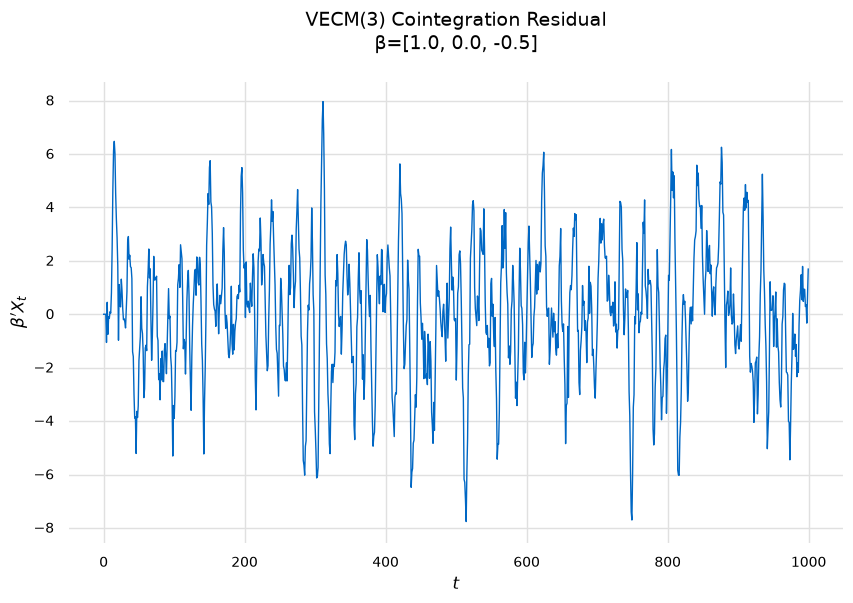

In [68]:
coint = beta_est.T[0] * xt.T / beta_est.T[0][0]
residual = numpy.sum(coint, axis=1)

title = f"VECM(3) Cointegration Residual\nβ=[{β[0,0]}, {β[0,1]}, {β[0,2]}]"
curve(residual, title=title, xlabel=r"$t$", ylabel=r"$\beta^\prime X_t$", lw=1, title_offset=0.05)

In [69]:
result, _ = adf.compute_adf_test(residual)
result.summary()

╒════════════════╤═══════════════╕
│ Test Statistic │ -10.6847      │
├────────────────┼───────────────┤
│ pvalue         │   3.30534e-19 │
├────────────────┼───────────────┤
│ Lags           │   6           │
├────────────────┼───────────────┤
│ Number Obs     │ 993           │
╘════════════════╧═══════════════╛
╒════════════════╤══════════════════╤══════════╕
│ Significance   │   Critical Value │ Result   │
╞════════════════╪══════════════════╪══════════╡
│ 1%             │         -2.568   │ Failed   │
├────────────────┼──────────────────┼──────────┤
│ 5%             │         -1.94127 │ Failed   │
├────────────────┼──────────────────┼──────────┤
│ 10%            │         -1.61656 │ Failed   │
╘════════════════╧══════════════════╧══════════╛


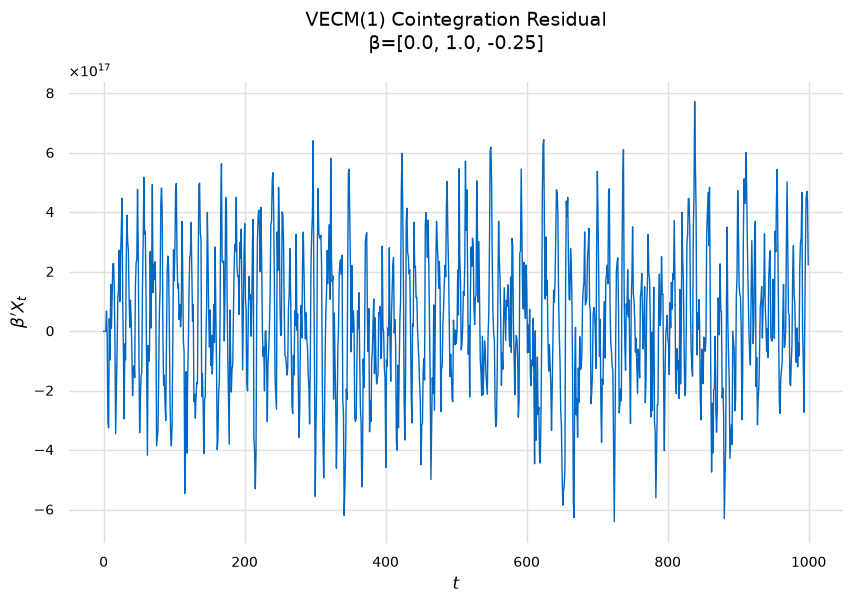

In [70]:
coint = beta_est.T[1] * xt.T / beta_est.T[1][0]
residual = numpy.sum(coint, axis=1)

title = f"VECM(1) Cointegration Residual\nβ=[{β[1,0]}, {β[1,1]}, {β[1,2]}]"
curve(residual, title=title, xlabel=r"$t$", ylabel=r"$\beta^\prime X_t$", lw=1, title_offset=0.05)

In [71]:
result, _ = adf.compute_adf_test(residual)
result.summary()

╒════════════════╤═══════════════╕
│ Test Statistic │ -13.7034      │
├────────────────┼───────────────┤
│ pvalue         │   7.62423e-25 │
├────────────────┼───────────────┤
│ Lags           │   5           │
├────────────────┼───────────────┤
│ Number Obs     │ 994           │
╘════════════════╧═══════════════╛
╒════════════════╤══════════════════╤══════════╕
│ Significance   │   Critical Value │ Result   │
╞════════════════╪══════════════════╪══════════╡
│ 1%             │         -2.56799 │ Failed   │
├────────────────┼──────────────────┼──────────┤
│ 5%             │         -1.94127 │ Failed   │
├────────────────┼──────────────────┼──────────┤
│ 10%            │         -1.61656 │ Failed   │
╘════════════════╧══════════════════╧══════════╛
